In [64]:
# !pip install tensorflow
# !pip install tensorflow-gpu
!pip install nvidia-cudnn-cu12
!pip install mediapipe

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [65]:
import os
import time
import math

import cv2
import numpy as np


Dataset:
- https://spandh.dcs.shef.ac.uk//gridcorpus/

Medium Article:
- https://medium.com/towards-data-science/designing-your-neural-networks-a5e4617027ed


Inputs: 
- [ ] Organise Dataset of choice in files 
    - Silentframes - format: {filename}_sil_x.mpg
    - OneWordframes -format: {filename}_word_x.mpg x represents the line number in the file
    - Multiword frames?? - {stiched from one word frames using x value to verify continuity} 
- [ ] Generate consistent script to iterate through files
- [ ] Catogerise files into relevant categories (speaking frames: non-speaking frames)
- [ ] Remove excess pixels and standardise image size
- [ ] Numpyify and injest from model

Dataset of Choice is LipNet
Key folders:
S1 - contains video audio footage
Alignments/S1 - contains aligned audio transcriptions

In [66]:
# LIPNET_S1_DIR = "/media/tymstr/Expansion/DiarizeDatabase/lipnetdata/s1"
# LIPNET_ALIGNMENTS_DIR = "/media/tymstr/Expansion/DiarizeDatabase/lipnetdata/alignments/s1"

# GRID_S1_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/s1"
# GRID_ALIGNMENTS_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/align"

FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

TEST_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdatatest"

# TEST_ALIGNMENT_DIR = "/media/tymstr/Expansion/DiarizeDatabase/testmodeldata/align"
# TEST_S1_DIR = "/media/tymstr/Expansion/DiarizeDatabase/testmodeldata/S1"

# VALIDATION_ALIGNMENT_DIR = "/media/tymstr/Expansion/DiarizeDatabase/validationdata/align"
# VALIDATION_S1_DIR = "/media/tymstr/Expansion/DiarizeDatabase/validationdata/S2"

def getAlignFiles(ALIGNMENTS_DIR: str):
    files = []
    for file in os.listdir(ALIGNMENTS_DIR):
        files.append(file)
    return files

def getVideoFiles(S1_DIR: str):
    files = []
    for file in os.listdir(S1_DIR):
        files.append(file)

    return files

def deconstructAlign(dir, filename):
    alignment_array = []
    y = dir + "/" + filename
    with open(y, 'r') as file:
        for line in file:
            alignment_array.append(line.strip('\n').split(" "))
    
    return alignment_array

def deconstructS1(dir, i):
    x = getVideoFiles(dir)[i]
    y = dir + "/" + x
    video = cv2.VideoCapture(y)
    num_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    success = True
    count = 0
    while success:
        success, img = video.read()
        if success==False:
            break
        count += 1
        
 
def calculateClips(filename, alignment_array, vid_folder):
    # alignment_array = deconstructAlign(GRID_ALIGNMENTS_DIR,0)
    # filename  = getAlignFiles(GRID_ALIGNMENTS_DIR)[0]
    clips = []
    for alignment in alignment_array:
        start, end, word = alignment
        start_frame = math.ceil(int(start)*0.001)
        end_frame = math.ceil(int(end)*0.001)
        # print("Start Frame:", start_frame, "End Frame:", end_frame, "Word:", word)

        clips.append([filename, start_frame, end_frame, word, vid_folder])

    return clips
# print(deconstructAlign(GRID_ALIGNMENTS_DIR,0))

# deconstructS1(GRID_S1_DIR,0)
def allClips(folder): 
    all_clips = []#hold all clips in form [filename, start_frame, end_frame, word]
    #for all files in all folders
    for subject in os.listdir(folder):
        try:
            align_folder = folder + "/" + subject + "/align"
            for filename in getAlignFiles(align_folder):
                alignment_array = deconstructAlign(align_folder,filename)
                vid_folder = folder + "/" + subject + "/" + subject
                video_clips = calculateClips(filename, alignment_array, vid_folder)#replace folder with videopath or alignpath
                for clip in video_clips:
                    all_clips.append(clip)
        except:
            pass

    return np.array(all_clips)

# # x = allClips(FULL_GRID_DIR + "/S1/align")
# for subject in os.listdir(FULL_GRID_DIR):
#     try:
#         video_list = os.listdir(FULL_GRID_DIR + "/" + subject + "/" + subject)
#         align_list = os.listdir(FULL_GRID_DIR + "/" + subject + "/align")
#         print(subject, align_list)
#     except:
#         print("non existant", subject)
#Given a file, 0, 23000
#return frames?

# print((allClips(FULL_GRID_DIR)))

# To determine the size of the input find the large amount of time a person is saying a single word (exclude silence?)
# Lipnet Organise Folder for classified data

Calculate Frame to alignment

Numofframes = cv2.CAP_PROP_FRAME_COUNT() // 
length of video (seconds) = ffmpeg -i bbaf2n.mpg 2>&1 | grep "Duration"


1.
Khz to Time
X khz / 25000 = time (seconds)
2.
Time to Frames
Time / Clip time = frame / num of frames
3.def:
khz to frames relationship
((X khz / 25000) / Clip time) x num of frames =~ frame

Given a .align for each line in .align
startframe, endframe = khztoframes(startvalue), khztoframes(endvalue)
if word == sil:
    add to non talking dataset
else:
    add to talking dataset

In [67]:
import tensorflow as tf
import mediapipe as mp

In [68]:
def exampleFrame():
    dir = GRID_S1_DIR
    x = getVideoFiles(dir)[0]
    y = dir + "/" + x
    video = cv2.VideoCapture(y)
    video.set(cv2.CAP_PROP_POS_FRAMES, 0)
    res, frame = video.read()
    
    return frame
    

In [69]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def findMouth(img, output):
    points = []
    dict = {}
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if id in MOUTH_LANDMARKS:
                        points.append((x,y))
                        dict[id] = (x,y)
    except:
        points.append((41,61))
        print("failed to find mouth")
    if output == "points":            
        return points
    else:
        return dict
    

I0000 00:00:1742941260.457641   10444 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1742941260.497808   62252 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2


In [70]:
# x = findMouth(exampleFrame(), "points")
# print(x)
# y, z = x[0]
# print(y, z)

W0000 00:00:1742941260.501764   62247 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1742941260.512843   62246 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [71]:
# Frames from video returns a numpy array

#large shufflable list
# list = [[filename, word, startframe, endframe], ...]  (This list will be defined/shuffled in Frame Generator)

#exampleframe = cv2.imread(image_path)

def formatFrames(frame, output_size):
    try:
        mouthpoints = findMouth(frame, "points")
        x,y = mouthpoints[0]
        # print(type(frame))
        #Resize image around the mouth
        new_frame = frame[y-40:y+60,x-50:x+50,:]
        
        # cv2.waitKey(0)
        # cv2.destroyAllWindows()
        #Convert into an acceptable format
    except:
        new_frame = frame[0:100, 0:100]


    new_frame = tf.image.convert_image_dtype(new_frame, tf.float32)
    new_frame = tf.image.resize_with_pad(new_frame, *output_size)
    return new_frame


# formatFrames(exampleFrame(), (100, 100))

In [72]:
#large shufflable list
# list = [[filename, word, startframe, endframe], ...]  (This list will be defined/shuffled in Frame Generator)
#Given a videopath
# calculateClips(video_path)
#AllClips(GRID_ALIGNMENTS_DIR)

import random
import numpy as np


def framesFromVideo(video_path, clip_name, clip_start, clip_end, clip_word):
    
    result = []
    full_path = video_path + "/" + clip_name
    video = cv2.VideoCapture(full_path)

    
    if int(clip_end) >= 11:
        for i in range(11, 1, -1):
            video.set(cv2.CAP_PROP_POS_FRAMES, int(clip_end)-i)
            res, frame = video.read()
            if not res:
                print("failed to read" + clip_name + clip_word)
                # print("i:", i)
                #This is being invoked quite often figure out why
                return [0]

            result.append(formatFrames(frame, (100,100)))
    else:
        clip_length = min(int(clip_end) - int(clip_start), 10)
        
        # print("Clip length:" , clip_length)
        for i in range(clip_length):
            video.set(cv2.CAP_PROP_POS_FRAMES, int(clip_start)+i)
            res, frame = video.read()
            if not res:
                print("I've pissed me self in the else statement sir")
                return [0]
            result.append(formatFrames(frame, (100,100)))
        remaining_frames = [result[-1]] * (10-len(result))
        result += remaining_frames
        # print("Result length:" , len(result))
        # print("Remaining Frames length:" , len(remaining_frames))

    #return  a numpy array of the frames
    video.release()
    # if len(result) == 0:
    #     return np.array([])
    

    result = np.array(result)[..., [2,1,0]]

    return result


def clipsOrganised(path):
    ALL_CLIPS = allClips(path)
    talking_clips = []
    non_talking_clips = []
    unshuffled_clips_array = []
    for i in range(len(ALL_CLIPS)):
        clip_name, clips_start, clip_end, clip_word, video_folder = ALL_CLIPS[i]
        if clip_word != "sil":
            label = 1
            talking_clips.append(ALL_CLIPS[i]) 
        else:
            label = 0
            non_talking_clips.append(ALL_CLIPS[i])


    num_ntc = len(non_talking_clips)
    num_tc = len(talking_clips)

    if num_ntc < num_tc:
        unshuffled_clips_array.append(non_talking_clips[num_ntc-50:])
        unshuffled_clips_array.append(talking_clips[num_ntc-50:])
    else:
        unshuffled_clips_array.append(non_talking_clips[num_tc-50:])
        unshuffled_clips_array.append(talking_clips[num_tc-50:])

    return talking_clips + non_talking_clips

class FrameGenerator():
    def __init__(self, dataset_path, training=False, totalclips=10000):
        # self.align_path = align_path
        # self.video_path = video_path
        self.dataset_path = dataset_path
        self.training = training
        self.totalclips = totalclips
        
    pass


    def __call__(self):
        ALL_CLIPS = clipsOrganised(self.dataset_path)

    
        if self.training:
            np.random.shuffle(ALL_CLIPS)

        for i in range(self.totalclips):
            clip_name, clips_start, clip_end, clip_word, video_path = ALL_CLIPS[i]
            video_clip_name = clip_name.split(".")[0]+".mpg"
            video_frames = framesFromVideo(video_path, video_clip_name, clips_start, clip_end, clip_word)

            try:
                if video_frames == [0]:
                    continue
            except:
                continue
            if clip_word != "sil":
                label = 1
            else:
                label = 0

            # print(video_clip_name, len(video_frames), label)
            yield video_frames, label

        #returns a set of frames with their associated label


In [73]:
def LandmarkMovement(video_path, clip_name, clip_start, clip_end, clip_word):
    # Returns numpy array from video
    result = []
    full_path = video_path + "/" + clip_name
    video = cv2.VideoCapture(full_path)

    if int(clip_end) >= 11:
        for i in range(11, 1, -1):
            video.set(cv2.CAP_PROP_POS_FRAMES, int(clip_end)-i)
            res, frame = video.read()
            if not res:
                print("failed to read")
                return 0

            result.append(findMouth(frame, "points"))
    else:
        clip_length = min(int(clip_end) - int(clip_start), 10)
        
        for i in range(clip_length):
            video.set(cv2.CAP_PROP_POS_FRAMES, int(clip_start)+i)
            res, frame = video.read()
            if not res:
                print("I've pissed me self in the else statement sir")
                return 0
            result.append(findMouth(frame, "points"))
        remaining_frames = [result[-1]] * (10-len(result))
        result += remaining_frames
        # print("Result length:" , len(result))
        # print("Remaining Frames length:" , len(remaining_frames))

    #return  a numpy array of the frames
    video.release()
    # if len(result) == 0:
    #     return np.array([])
    

    # result = np.array(result)[..., [2,1,0]]

    pass



class LandmarkGenerator():
    def __init__(self, dataset_path, training=False, totalclips=10000):
        self.dataset_path = dataset_path
        self.training = training
        self.totalclips = totalclips
        
    pass


    def __call__(self):
        ALL_CLIPS = clipsOrganised(self.dataset_path)

    
        if self.training:
            np.random.shuffle(ALL_CLIPS)

        for i in range(self.totalclips):
            clip_name, clips_start, clip_end, clip_word, video_path = ALL_CLIPS[i]
            video_clip_name = clip_name.split(".")[0]+".mpg"
            video_frames = LandmarkMovement(video_path, video_clip_name, clips_start, clip_end, clip_word)

            try:
                if len(video_frames) == 0:
                    continue
            except:
                continue
            if clip_word != "sil":
                label = 1
            else:
                label = 0

            # print(video_clip_name, len(video_frames), label)
            yield video_frames, label



Testclips = clipsOrganised(FULL_GRID_DIR)
clip_name, clips_start, clip_end, clip_word, video_path = Testclips[2]
print(LandmarkMovement(video_path, clip_name, clips_start, clip_end, clip_word))

failed to read
0


In [74]:
# fg = FrameGenerator(TEST_GRID_DIR, True)

# frames, label = next(fg())

# print(f"Shape: {frames.shape}")
# print(f"Label: {label}")

In [75]:
output_signature = (tf.TensorSpec(shape = (None,None, None,3), dtype = tf.float32),
                    tf.TensorSpec(shape = (), dtype = tf.int16))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(FULL_GRID_DIR, True, 24000),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(FULL_GRID_DIR, True, 6000),
                                          output_signature = output_signature)
# test_ds = tf.data.Dataset.from_generator(FrameGenerator(TEST_GRID_DIR, True),
#                                           output_signature = output_signature)


In [76]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
# test_ds = test_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

In [77]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)
# test_ds = test_ds.batch(2)

In [78]:
# train_frames, train_labels = next(iter(train_ds),)
  
# val_frames, val_labels = next(iter(val_ds))clip_end

In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

### Model 2

In [80]:


# model2 = tf.keras.Sequential()
# model2.add(Conv3D(128, 3, input_shape=(3,100,100,3), padding='same'))
# model2.add(Activation('relu'))
# model2.add(MaxPool3D((1,2,2)))clip_length

# model2.add(Conv3D(256, 3, padding='same'))
# model2.add(Activation('relu'))
# model2.add(MaxPool3D((1,2,2)))

# # model2.add(Conv3D(75, 3, padding='same'))
# # model2.add(Activation('relu'))
# # model2.add(MaxPool3D((1,2,2)))

# model2.add(TimeDistributed(Flatten()))

# model2.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
# model2.add(Dropout(.5))

# model2.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
# model2.add(Dropout(.5))

# model2.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

In [81]:

# model2.compile(optimizer = 'adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
#               metrics=['accuracy'])

# model2.fit(train_ds, 
#           epochs = 10,
#           validation_data = val_ds,
#           callbacks = tf.keras.callbacks.EarlyStopping(patience = 2, monitor = 'val_loss'))

### Model 1

In [82]:
# net = tf.keras.applications.EfficientNetB0(include_top = False)
# net.trainable = False

# model = tf.keras.Sequential([
#     tf.keras.layers.Rescaling(scale=255),
#     tf.keras.layers.TimeDistributed(net),
#     tf.keras.layers.Dense(10),
#     tf.keras.layers.GlobalAveragePooling3D()
# ])

# model.compile(optimizer = 'adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
#               metrics=['accuracy'])

# model.fit(train_ds, 
#           epochs = 10,
#           validation_data = val_ds,
#           callbacks = tf.keras.callbacks.EarlyStopping(patience = 2, monitor = 'val_loss'))


### Model 3

In [83]:
from tensorflow.keras import layers, models

# model3 = models.Sequential([
#     layers.ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same', return_sequences=True, input_shape=(10, 100, 100, 3)),
#     layers.BatchNormalization(),
#     layers.ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=True),
#     layers.BatchNormalization(),
#     layers.ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False),
#     layers.BatchNormalization(),
#     layers.Flatten(),
#     # layers.Dense(128, activation='relu'),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(1, activation='sigmoid')
# ])

# model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# model3.fit(train_ds, 
#           epochs = 10,
#           validation_data = val_ds,
#           callbacks = tf.keras.callbacks.EarlyStopping(patience = 2, monitor = 'val_loss'))


### Model 4

In [84]:
input_shape = (10, 100, 100, 3)

model4 = models.Sequential([
    # Input Layer
    layers.Input(shape=input_shape),

    # (2+1)D Conv Block 1
    layers.Conv3D(32, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(32, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(1, 2, 2)),

    # (2+1)D Conv Block 2
    layers.Conv3D(64, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(64, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # (2+1)D Conv Block 3
    layers.Conv3D(128, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(128, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # Global Feature Aggregation
    layers.GlobalAveragePooling3D(),
    layers.Dropout(0.5),

    # TimeDistributed(Flatten()),

    # Bidirectional(LSTM(128, return_sequences=True)),
    # Dropout(0.3),
    
    # Bidirectional(LSTM(128, return_sequences=True)),
    # Dropout(0.3),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer (Binary Classification)
    layers.Dense(1, activation='sigmoid')  # Change from softmax to sigmoid
])

# Compile Model
model4.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy'])

# Model Summary
history = model4.fit(train_ds, 
          epochs = 9,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

ValueError: Input 0 of layer "bidirectional_6" is incompatible with the layer: expected ndim=3, found ndim=5. Full shape received: (None, 2, 12, 12, 128)

In [89]:
model4.save_weights('./17_03_30k_5S.weights.h5')

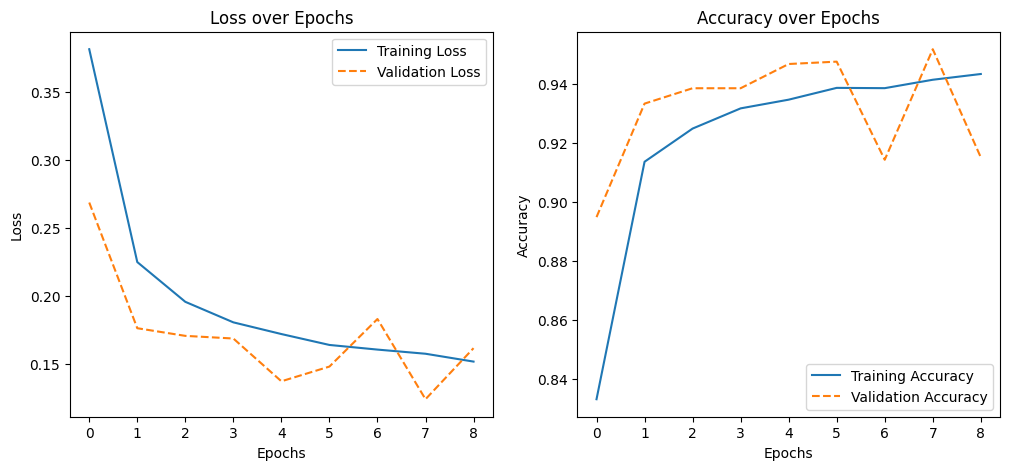

In [90]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [91]:

def getVideoFiles(S1_DIR: str):
    files = []
    for file in os.listdir(S1_DIR):
        files.append(file)

    return files

def deconstructAlign(dir, filename):
    alignment_array = []
    y = dir + "/" + filename
    with open(y, 'r') as file:
        for line in file:
            alignment_array.append(line.strip('\n').split(" "))
    
    return alignment_array



In [92]:
import numpy as np
from PIL import Image
import imageio



test_samples = []
example_input = np.random.rand(1, 10, 100, 100, 3).astype(np.float32)
# example_frames = next(iter(test_ds))

single_frame = np.random.rand(100, 100, 3).astype(np.float32)

# Repeat the frame 10 times to create a sequence
video_clip = np.tile(single_frame, (10, 1, 1, 1))  # shape will be (10, 100, 100, 3)

# Now add the batch dimension, resulting in shape (1, 10, 100, 100, 3)
example_input2 = np.expand_dims(video_clip, axis=0)

for i in range(1):
    prediction = model5.predict(example_input2)
    # next(iter(train_ds))
    print(prediction[0][0])
    



NameError: name 'model5' is not defined

How does a 3D convNN injest video?
https://www.tensorflow.org/tutorials/load_data/video

then

https://www.tensorflow.org/tutorials/video/video_classification

then consider

MoviNet for streaming action recognition


Outputs:
One neuron with the probalility of the positive class

Layers:
- Lookup YOLO ResNet and VGG for processing image and speech data
-Same number of neurons for all layers should suffice, to increase accuracy consider using a large first layer filtered into smaller layers.(later) More layer > more neurons
- I’d recommend starting with 1–5 layers and 1–100 neurons and slowly adding more layers and neurons until you start overfitting

Assessing Layers:
- You can track your loss and accuracy within your Weights and Biases dashboard to see which hidden layers + hidden neurons combo leads to the best loss
- Andrej Karpathy also recommends the overfit then regularize approach — “first get a model large enough that it can overfit (i.e. focus on training loss) and then regularize it appropriately (give up some training loss to improve the validation loss).”
-

Loss Function:
- Cross-entropy will serve you well in most cases.

Batch Size:
- Smaller may often be better

Number of epochs:
- Start with an early number of epochs and use **Early Stopping** to halt training when performance stops improving

Scaling features:
- currently scaling based on distance from point on mouth using pixels, consider a scaling relative to the mouth landmarks??


Learning Rate:
- To find the best learning rate, start with a very low value (10^-6) and slowly multiply it by a constant until it reaches a very high value (e.g. 10). Measure your model performance (vs the log of your learning rate) in your Weights and Biases dashboard to determine which rate served you well for your problem.
- The best learning rate is usually half of the learning rate that causes the model to diverge. Feel free to set different values for learn_rate in the accompanying code and seeing how it affects model performance to develop your intuition around learning rates.
- recommend using the Learning Rate finder method proposed by Leslie Smith.

Momentum:
- Gradient descent to consider momentum and local minimas
- In general, you want your momentum value to be very close to one. 0.9 is a good place to start for smaller datasets

Vanishing + Exploding Gradients:
- Activation Functions
    - User ReLU for now
    - Revisit if unhappy with networks learning rate
